In [2]:
import pandas as pd
import numpy as np
import math
from scipy import optimize
from matplotlib import pyplot as plt
import os 
import re

In [3]:
path = os.getcwd()
path

'/Users/linaatanasova/Documents/pycourse/qfi/thesis_code'

## Interest rate calibration

In [ ]:
int_rate = pd.read_excel(path+"data/Spot-Yield-Curve-Analysis_01-01-2015_FACTSET.xlsx", sheet_name='SpotCurve')
int_rate = int_rate[1:122] #from 1M to 10Y 1M 
int_rate['SPOTTRYUS-FDS'] = int_rate['SPOTTRYUS-FDS'].astype('float')
int_rate.tail(10)

,Tenor,SPOTTRYUS-FDS
112,9Y 4M,2.190349
113,9Y 5M,2.195020
114,9Y 6M,2.199495
115,9Y 7M,2.204081
116,9Y 8M,2.208641
117,9Y 9M,2.213033
118,9Y 10M,2.217551
119,9Y 11M,2.221903
120,10Y,2.226381
121,10Y 1M,2.230850


In [181]:
#Convert Tenor to Year fractions
tenor = pd.DataFrame( int_rate['Tenor'].str.extract(pat = r'(\d*)(\w.*)', expand=True))
tenor = pd.concat([tenor, tenor[1].str.extract(pat = r'(\D*)(\d*)', expand=True)], axis=1)
tenor.iloc[:,3] = tenor.iloc[:,3].replace('', 0)
int_rate.loc[:,'y_frac'] = tenor.iloc[:,0].astype('float') + tenor.iloc[:,3].astype('float')/12
int_rate.loc[:11,'y_frac'] = int_rate['y_frac'][:11]/12 #first 11 rows are in months
int_rate.head(20)

,Tenor,SPOTTRYUS-FDS,y_frac
1,1M,0.049399,0.083333
2,2M,0.067208,0.166667
3,3M,0.087299,0.250000
4,4M,0.107162,0.333333
5,5M,0.128173,0.416667
6,6M,0.149027,0.500000
7,7M,0.171164,0.583333
8,8M,0.193954,0.666667
9,9M,0.216678,0.750000
10,10M,0.240905,0.833333


In [182]:
int_rate.describe()

,SPOTTRYUS-FDS,y_frac
count,121.000000,121.000000
mean,1.466894,5.083333
std,0.690401,2.922811
min,0.049399,0.083333
25%,0.949253,2.583333
50%,1.699102,5.083333
75%,2.065935,7.583333
max,2.230850,10.083333


### CIR Process

$$
dr_t = a(b - r_t) \, dt + \sigma \sqrt{r_t} \, dW_t
$$

- a > 0 : speed or mean reversion coefficient
- $ b \in R $ : long term mean
- $ \sigma > 0 $ : volatility

From solving the CIR bond pricing PDE, we get that bond prices are given by: 

$$
P(t,T) = A(t,T) e^{-B(t,T)r_t}
$$

with 
$$
A(t,T) = \left( \frac{2h e^{\tfrac{(a+h)(T-t)}{2}}}{2h + (a+h)\left(e^{h(T-t)} - 1\right)} \right)^{\tfrac{2ab}{\sigma^2}}
$$

$$
B(t,T) = \frac{2\left(e^{h(T-t)} - 1\right)}{2h + (a+h)\left(e^{h(T-t)} - 1\right)}
$$

$$
h = \sqrt{a^2 + 2\sigma^2}
$$

We are taking a **static approach**, as in we calibrate the data based on only one point in time: on 01/01/2015 we observe the interest rate for different maturities (from 1M to 10Y1M).  

In [183]:
#Bond price CIR model
def bond_price_CIR(a,b,r0,sigma,T): # supposing t=0, we only need maturity T
        h = math.sqrt(a**2 + 2*sigma**2)
        numerator_A = 2*h*np.exp((a+h)*T/2)
        denominator_A = 2*h + (a+h)*(np.exp(h*T)-1)
        A = (numerator_A/denominator_A)**(2*a*b/sigma**2)
        B = 2*(np.exp(h*T)-1)/(2*h + (a+h)*(np.exp(h*T)-1))
            
        return A * np.exp(-B*r0) # should be an np.array


In [ ]:
#CIR calibration: objective function
def CIR_objective_fct(params):
    a, b, r0, sigma = params
    if a <= 0 or r0 <= 0 or sigma <= 0: #must be positive values
        return np.inf
    if 2*a*b < sigma**2: #Feller condition for non-zero interest rates
        return np.inf
    else:
        model_prices = bond_price_CIR(a,b,r0,sigma,int_rate['y_frac'])
        market_prices = np.exp(-int_rate['SPOTTRYUS-FDS']/100*int_rate['y_frac']) #continuous compounding
        return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))  # MAPE (Mean Absolute Percentage Error)

In [185]:
# Global optimization
bounds = [(0.00001, 1), (0.00001, 1), (0.00001, 0.1), (0.00001, 1)] # bounds for a, b, r0, sigma
res1 = optimize.brute(CIR_objective_fct, bounds, Ns=15)

a_opt_gl, b_opt_gl, r0_opt_gl, sigma_opt_gl = res1

df_global = pd.DataFrame(
    {"Global Optimization": [a_opt_gl, b_opt_gl, r0_opt_gl, sigma_opt_gl]},
    index=["a", "b", "r0", "sigma"]
)
print("Global optimization results:")
display(df_global)

Global optimization results:


,Global Optimization
a,3.711355e-01
b,3.093515e-02
r0,3.058306e-08
sigma,6.848391e-02


In [ ]:
#Local optimization
initial_guess = res1 #passing the result of global optimization
res2 = optimize.minimize(CIR_objective_fct, initial_guess, method='Nelder-Mead',bounds = [(1e-5, 1), (1e-5, 1), (1e-8, 0.1), (1e-5, 1)] )
a_opt, b_opt, r0_opt, sigma_opt = res2.x

df_local = pd.DataFrame(
    {"Local optimization": [a_opt, b_opt, r0_opt, sigma_opt]},
     index = ["a", "b", "r0", "sigma"]
)
# results
print("Local optimization results:")
display(df_local)

# notice r0 = 0

Local optimization results:


,Local optimization
a,3.422757e-01
b,3.293821e-02
r0,1.034148e-08
sigma,1.501482e-01


In [191]:
# MAPE comparison
mape_local = CIR_objective_fct(res2.x)
mape_global = CIR_objective_fct(res1)
df_mape = pd.DataFrame(
    {"MAPE": [mape_global, mape_local]},
    index = ["Global optimization", "Local optimization"]
)
df_mape


,MAPE
Global optimization,0.001766
Local optimization,0.001719


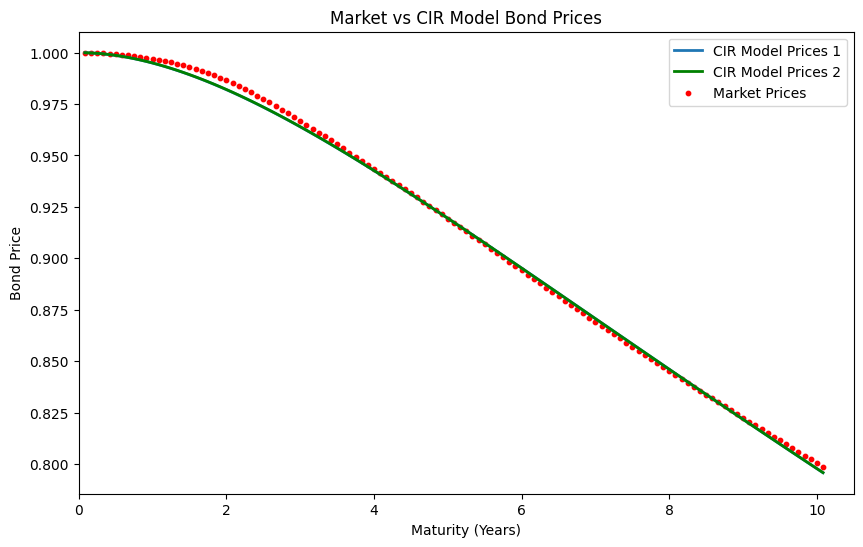

In [192]:
market_prices = np.exp(-int_rate['SPOTTRYUS-FDS']*int_rate['y_frac']/100)
model_prices_1 = bond_price_CIR(a_opt_gl,b_opt_gl,r0_opt_gl,sigma_opt_gl,int_rate['y_frac'])
model_prices_2 = bond_price_CIR(a_opt,b_opt,r0_opt,sigma_opt,int_rate['y_frac'])

plt.figure(figsize=(10,6))
plt.plot(int_rate['y_frac'], model_prices_1, label='CIR Model Prices 1', linestyle='-', linewidth=2)
plt.plot(int_rate['y_frac'], model_prices_2, label='CIR Model Prices 2', linestyle='-', color='g', linewidth=2)
plt.scatter(int_rate['y_frac'], market_prices, label='Market Prices', color='red', s=10)
plt.legend()
plt.xlim(0, 10.5)
plt.xlabel('Maturity (Years)')
plt.ylabel('Bond Price')
plt.title('Market vs CIR Model Bond Prices') 
plt.show()               

### 01/10/2019

In [193]:
### Using 01/10/2019 data
int_rate = pd.read_excel(path+"/Spot-Yield-Curve-Analysis_01-10-2019_FACTSET.xlsx", sheet_name='SpotCurve')
int_rate = int_rate[1:122] #from 1M to 10Y 1M 
int_rate['SPOTTRYUS-FDS'] = int_rate['SPOTTRYUS-FDS'].astype('float')
#Convert Tenor to Year fractions
tenor = pd.DataFrame( int_rate['Tenor'].str.extract(pat = r'(\d*)(\w.*)', expand=True))
tenor = pd.concat([tenor, tenor[1].str.extract(pat = r'(\D*)(\d*)', expand=True)], axis=1)
tenor.iloc[:,3] = tenor.iloc[:,3].replace('', 0)
int_rate.loc[:,'y_frac'] = tenor.iloc[:,0].astype('float') + tenor.iloc[:,3].astype('float')/12
int_rate.loc[:11,'y_frac'] = int_rate['y_frac'][:11]/12 #first 11 rows are in months
int_rate.head(10)              

,Tenor,SPOTTRYUS-FDS,y_frac
1,1M,2.432941,0.083333
2,2M,2.464178,0.166667
3,3M,2.494770,0.250000
4,4M,2.520623,0.333333
5,5M,2.543675,0.416667
6,6M,2.562658,0.500000
7,7M,2.579056,0.583333
8,8M,2.592417,0.666667
9,9M,2.602663,0.750000
10,10M,2.610709,0.833333


In [194]:
# Global optimization
bounds = [(0.00001, 1), (0.00001, 1), (0.00001, 0.1), (0.00001, 1)] # bounds for a, b, r0, sigma
res1 = optimize.brute(CIR_objective_fct, bounds, Ns=15)

a_opt_gl, b_opt_gl, r0_opt_gl, sigma_opt_gl = res1

df_global = pd.DataFrame(
    {"Global Optimization": [a_opt_gl, b_opt_gl, r0_opt_gl, sigma_opt_gl]},
    index=["a", "b", "r0", "sigma"]
)
print("Global optimization results:")
display(df_global)

Global optimization results:


,Global Optimization
a,0.118128
b,0.034701
r0,0.023074
sigma,0.040870


In [195]:
# Local optimization
initial_guess = res1 #passing the result of global optimization
res2 = optimize.minimize(CIR_objective_fct, initial_guess, method='Nelder-Mead',bounds = [(1e-5, 1), (1e-5, 1), (1e-5, 0.1), (1e-5, 1)] )
a_opt, b_opt, r0_opt, sigma_opt = res2.x        
df_local = pd.DataFrame(
    {"Local optimization": [a_opt, b_opt, r0_opt, sigma_opt]},
     index = ["a", "b", "r0", "sigma"]
)
# results
print("Local optimization results:")
display(df_local)

Local optimization results:


,Local optimization
a,0.050512
b,0.042175
r0,0.023674
sigma,0.015013


In [196]:
a_pap, b_pap, r0_pap, sigma_pap = (0.0150053,0.0343607,0.0150335,0.001003)
df_pap = pd.DataFrame(
    {"Ballestra et al.": [a_pap, b_pap, r0_pap, sigma_pap]},
     index = ["a", "b", "r0", "sigma"]
)
print("Local optimization results:")
pd.merge(df_local, df_pap, left_index=True, right_index=True)


Local optimization results:


,Local optimization,Ballestra et al.
a,0.050512,0.015005
b,0.042175,0.034361
r0,0.023674,0.015033
sigma,0.015013,0.001003


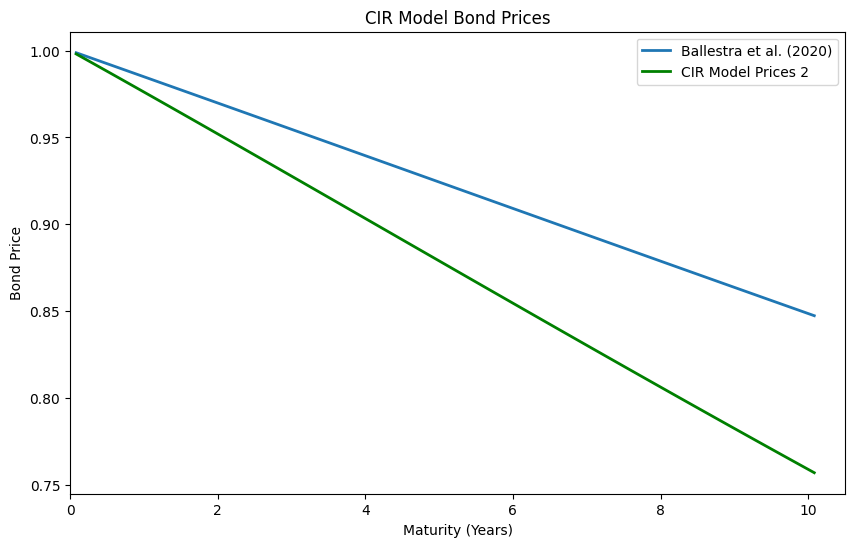

In [204]:
# CIR model in Ballestra et al. (2020)
model_prices = bond_price_CIR(a_pap, b_pap, r0_pap, sigma_pap ,int_rate['y_frac'])
model_prices_2 = bond_price_CIR(a_opt,b_opt,r0_opt,sigma_opt,int_rate['y_frac'])

plt.figure(figsize=(10,6))
plt.plot(int_rate['y_frac'], model_prices, label='Ballestra et al. (2020)', linestyle='-', linewidth=2)
plt.plot(int_rate['y_frac'], model_prices_2, label='CIR Model Prices 2', linestyle='-', color='g', linewidth=2)
plt.legend()
plt.xlim(0, 10.5)
plt.xlabel('Maturity (Years)')
plt.ylabel('Bond Price')
plt.title('CIR Model Bond Prices') 
plt.show()  

In [198]:
# Read the InterestRate_DataSet.txt file using pandas
B = pd.read_csv(path+'/InterestRate_DataSet.txt', skiprows=2, header=None)
B.columns = ['bond_price']
B.iloc[0] = 99.9609375
B.iloc[-1] = 80.5703125
B['bond_price']= B['bond_price'].astype('float')
display(B.head())
# missing maturities

,bond_price
0,99.960938
1,99.914062
2,99.914062
3,99.875000
4,99.835938


In [199]:
len(B['bond_price']) #there should be 310 values?

210

## Calibration to observed CDS spreads


*Ballestra et al. (2020)* give the following expression for the CDS spread: 

$$
\Pi_{CE}\big(x(t_0), r(t_0), t_0; T\big) =
\frac{
\Big(1 - f\big(x(t_0), T - t_0\big) e^{C(T - t_0) + D(T - t_0) r(t_0)}\Big)
(1 - \delta) P\big(r(t_0), t_0; T\big)
}{
\int_0^{T - t_0} f\big(x(t_0), s\big) e^{E_1(s) + E_2(s) r(t_0)} \, ds
}
$$


where

$$
f(x, \tau) = \left( \mathcal{L}^{-1} F \right)(x, \tau)
$$



with
$ \tau \in [0, T - t_0] $, and $ f $ is a suitable function whose **Laplace transform** $ F $ is derived in *Cathcart and El-Jahel (2006)*.

In our case $t_0 = 0$ and the Laplace transform is given by:
**expression (13)**
<!--
$$
\begin{aligned}
F(x, q) = \frac{2^{-1 - n} \pi \eta}{\sigma_x^2 \gamma^2 \sin(\pi n)} \left( \frac{cx}{x} \right)^\zeta \Bigg\{ & 
- I_n\left(\eta \left( \frac{cx}{x} \right)^\gamma \right) I_{-n}(\eta c^\gamma)(\eta c^\gamma)^{1+\xi+n} 
\Gamma\left( \frac{1+\xi+n}{2} \right) \\
& \times H\left(1+n, \frac{3+\xi+n}{2}, \frac{(nc^\gamma)^2}{4} \right) \\
- 2^{2n} I_n\left(\eta \left( \frac{cx}{x} \right)^\gamma \right) \Gamma\left( \frac{1+\xi-n}{2} \right)
\left( \eta \left( \frac{cx}{x} \right)^\gamma \right)^{1+\xi-n} \\
& \times H\left( \frac{1+\xi-n}{2}, 1 - n, \frac{3+\xi-n}{2} \right)
\cdot \frac{1}{4} \left( \eta \left( \frac{cx}{x} \right)^\gamma \right)^2 \\
+ 2^{2n} I_n\left(\eta \left( \frac{cx}{x} \right)^\gamma \right) (\eta c^\gamma)^{1+\xi-n}
\Gamma(1 - n) \Gamma\left( \frac{3+\xi-n}{2} \right) \\
& \times H\left( \frac{1+\xi-n}{2}, 1 - n, \frac{3+\xi-n}{2} \right), \frac{(nc^\gamma)^2}{4} \\
+ I_{-n}\left(\eta \left( \frac{cx}{x} \right)^\gamma \right)
\left( \eta \left( \frac{cx}{x} \right)^\gamma \right)^{1+\xi+n} 
\cdot \frac{\Gamma(1 - n) \Gamma\left( \frac{3+\xi-n}{2} \right)}
{\Gamma(1 + n) \Gamma\left( \frac{3+\xi+n}{2} \right)} \\
& \times H\left( \frac{1+\xi+n}{2}, 1 + n, \frac{3+\xi+n}{2} \right) \cdot \frac{1}{4}
\left( \eta \left( \frac{cx}{x} \right)^\gamma \right)^2 \Bigg\}

\end{aligned}
$$
-->

where

$$
\zeta = \frac{\alpha}{\sigma_x^2} - \frac{1}{2}, \quad
\gamma = \frac{1}{2}, \quad
\eta = \frac{\sqrt{8}}{\sigma_x}, \quad
n = \frac{1}{2} \sqrt{\zeta^2 + \frac{2q}{\sigma_x^2}}, \quad
\xi = - \frac{\zeta + \gamma}{\gamma}
$$

We will need the numerical inverse Laplace transform.

We assume the recovery rate ($\delta$) to be equal to 0.4 following most of the literature (Madan (2014)). It is assumed to be a safe assumption as it has been shown that  The parameters of the CE model that need to be computed, namely 
$$ x_0/x_l, α, σ^2_x, a, b, c $$ 
are obtained by minimizing the mean absolute percentage error (MAPE) between the empirical CDS spreads and the theoretical ones.

In addition, 
# Expressions for E₁(s) and E₂(s)

The two functions are:
$$ 
\[
E_1(s) = \frac{2 k \mu}{\sigma_r^2}
\ln\left(
\frac{2 q\, e^{\left(k - q - \frac{a\sigma_r^2}{k\mu}\right)\frac{s}{2}}}{
2q + (k - q)(1 - e^{-qs})}
\right),
\]
$$


\[
E_2(s) =
\frac{-2(b+1)(1 - e^{-qs})}{
2q + (k - q)(1 - e^{-qs})}.
\]
$$

In [20]:
cds = pd.read_excel(path+"/data/dataset_cds.xlsx")
cds.head()

,date,ticker,factset ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10,close price
0,2015-01-01,A,A-US,Agilent Technologies Inc,14.850,25.05,39.055,73.715,86.30,111.305,125.905,144.300,158.600,168.195,NaN
1,2015-01-02,A,A-US,Agilent Technologies Inc,14.855,25.15,39.160,73.600,86.40,111.510,126.100,144.375,158.775,168.375,NaN
2,2015-01-05,A,A-US,Agilent Technologies Inc,13.455,24.96,39.310,70.200,88.26,111.970,125.060,143.165,157.385,166.825,NaN
3,2015-01-06,A,A-US,Agilent Technologies Inc,15.535,24.88,39.300,72.680,91.10,116.610,130.890,150.365,165.655,175.885,NaN
4,2015-01-07,A,A-US,Agilent Technologies Inc,15.215,25.50,40.270,73.880,92.50,117.780,131.940,151.145,166.215,176.295,NaN


In [21]:
cds.drop(axis=1, columns="close price", inplace=True)
cds.head()

,date,ticker,factset ticker,company,PX1,PX2,PX3,PX4,PX5,PX6,PX7,PX8,PX9,PX10
0,2015-01-01,A,A-US,Agilent Technologies Inc,14.850,25.05,39.055,73.715,86.30,111.305,125.905,144.300,158.600,168.195
1,2015-01-02,A,A-US,Agilent Technologies Inc,14.855,25.15,39.160,73.600,86.40,111.510,126.100,144.375,158.775,168.375
2,2015-01-05,A,A-US,Agilent Technologies Inc,13.455,24.96,39.310,70.200,88.26,111.970,125.060,143.165,157.385,166.825
3,2015-01-06,A,A-US,Agilent Technologies Inc,15.535,24.88,39.300,72.680,91.10,116.610,130.890,150.365,165.655,175.885
4,2015-01-07,A,A-US,Agilent Technologies Inc,15.215,25.50,40.270,73.880,92.50,117.780,131.940,151.145,166.215,176.295


In [22]:
maturities = np.array([1, 2, 3, 4, 5, 7, 10])  # in years

In [ ]:
def CDS_price_CE(rec_rate, x_ratio, alpha, sigma_x, a, b, c, maturities):
   # SKELETON OF THE FUNCTION 
    ''' This function computes the CDS price using the CE model and gives the term structure of CDS spreads for a specific date.'''
    # CDS pricing using the CE model

    # PROTECTION LEG
    protection_leg = ((1 - inv_laplace_CE * np.exp(C(maturities))+D(maturities) * r_0) 
                      * (1-rec_rate) * bond_price_CIR(k_opt,mu_opt,r0_opt,sigma_r_opt,maturities))   # recovery rate delta = 0.4 assumed

    # PREMIUM LEG
    premium_leg = alpha * np.sum(bond_price_CIR(a_opt,b_opt,r0_opt,sigma_opt,maturities))
    
    price =  protection_leg / premium_leg 
    return price

In [ ]:
def CDS_objective_fct(params):
    x_ratio, alpha, sigma_x, a, b, c = params
    model_prices = cds_price_CE(x_ratio, alpha, sigma_x, a, b, c, maturities)
    market_prices = np.array([...])  # empirical CDS spreads
        return 1/len(market_prices) * np.sum(np.abs((market_prices - model_prices)/market_prices))  # MAPE (Mean Absolute Percentage Error)
